# Heart Disease Classification – Neural Network vs BDT

In this tutorial we compare two machine learning models:

- A small Neural Network (NN)
- A Boosted Decision Tree (BDT)

We use the Heart Disease Cleveland dataset to classify:

- 0 → No heart disease
- 1 → Heart disease

Since this is a medical application, we will carefully evaluate:

- Training behavior (over/underfitting)
- Feature importance
- Prediction distributions
- ROC curves
- Sensitivity and specificity

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nairods/Scies4Free-FastML-tutorial/blob/main/part0.ipynb)

## 1. Import Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
RANDOM_STATE = 42

## 2. Load and Inspect the Dataset

In [18]:
data = fetch_openml('heart-disease', version=1)

df = data.frame

X = df.drop(columns=['target'])
y = df['target']

print("\nFirst 5 rows of data:")
display(X.head())

print("\nClass distribution:")
print(pd.Series(y).value_counts())


First 5 rows of data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0



Class distribution:
target
1.0    165
0.0    138
Name: count, dtype: int64


## Feature explanation

| Feature | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3 categorical) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dL) |
| `fbs` | Fasting blood sugar > 120 mg/dL (1 = true, 0 = false) |
| `restecg` | Resting ECG results (0–2 categorical) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia type (1–3 categorical) |
| `target` | 1 = heart disease, 0 = no disease |

## 3. Train/Test Split

In [19]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_val
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 169
Validation samples: 43
Test samples: 91


### Data split policy (important)

We keep a **held-out test set** that is *not used during model development*.

- **Train**: used to fit model parameters (weights/trees).
- **Validation**: used to tune hyperparameters and for early stopping / model selection.
- **Test**: used **once at the end** for final reporting and comparison.

This avoids “test set leakage” (accidentally tuning on the test set).

## 4. Scale Features (for Neural Network)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## 5. Build and Train Small Neural Networks (Baseline + Anti-Overfitting)

We’ll start with a baseline model that tends to overfit, then compare three common mitigation techniques: early stopping, L2 regularization, and dropout.

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

input_dim = X_train_scaled.shape[1]


### 5.1 Baseline (likely to overfit)

We intentionally train longer to make overfitting more visible.

In [22]:
def build_baseline(input_dim):
 model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(12, activation='relu',),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

baseline = build_baseline(input_dim)
hist_baseline = baseline.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=80,
 batch_size=16,
 verbose=0
)


### 5.2 Early Stopping

Stops training when validation loss stops improving and restores the best weights.

In [23]:
early_stop = keras.callbacks.EarlyStopping(
 monitor='val_loss',
 patience=10,
 min_delta=1e-4,
 restore_best_weights=True
)

es_model = build_baseline(input_dim)
hist_es = es_model.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=200,
 batch_size=16,
 callbacks=[early_stop],
 verbose=0
)


### 5.3 L2 Regularization (weight decay)

Adds a penalty on large weights to reduce overfitting.

In [24]:
def build_l2(input_dim, l2=1e-3):
 model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(12, activation='relu', kernel_regularizer=regularizers.L2(l2)),
    layers.Dense(6, activation='relu', kernel_regularizer=regularizers.L2(l2)),
    layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

l2_model = build_l2(input_dim, l2=1e-3)
hist_l2 = l2_model.fit(
 X_train_scaled, y_train,
 validation_data=(X_val_scaled, y_val),
 epochs=80,
 batch_size=16,
 verbose=0
)


### 5.4 Dropout

Randomly drops activations during training to reduce co-adaptation.

In [25]:
def build_dropout(input_dim, rate=0.3):
 model = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(12, activation='relu'),
    layers.Dropout(rate),
    layers.Dense(6, activation='relu'),
    layers.Dropout(rate),
    layers.Dense(1, activation='sigmoid')
 ])
 model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 return model

do_model = build_dropout(input_dim, rate=0.3)
hist_do = do_model.fit(
 X_train_scaled, y_train,
 validation_split=0.2,
 epochs=80,
 batch_size=16,
 verbose=0
)


## 6. Training History (Compare Overfitting)

We plot train vs validation curves for loss and accuracy for all methods.

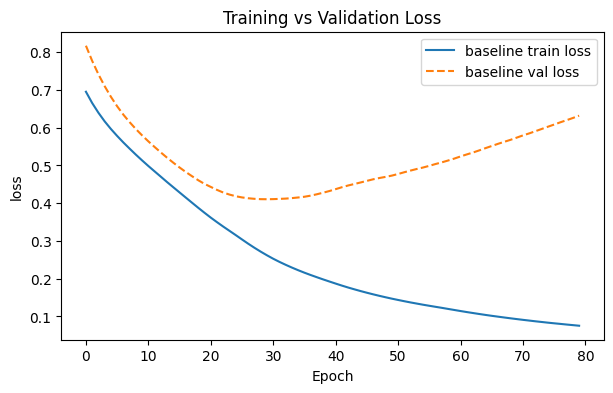

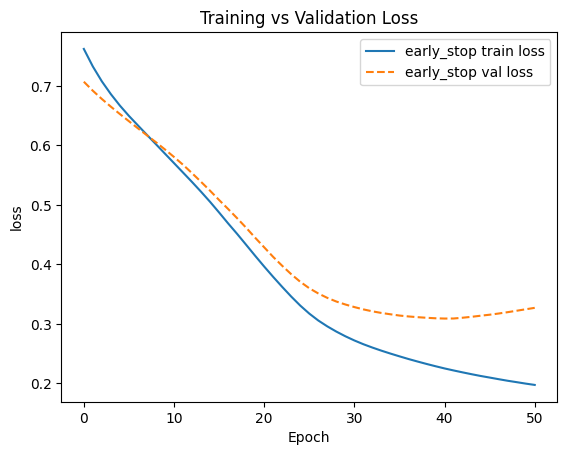

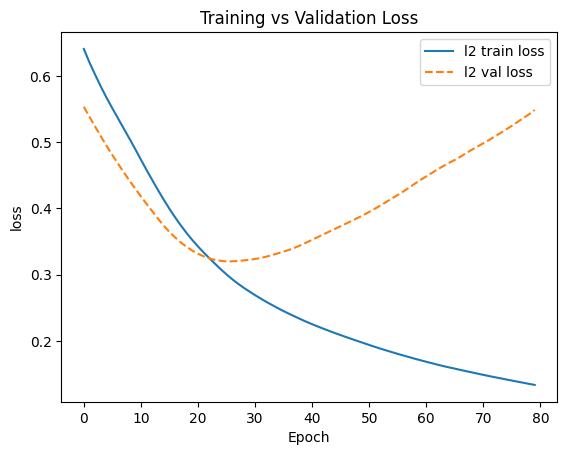

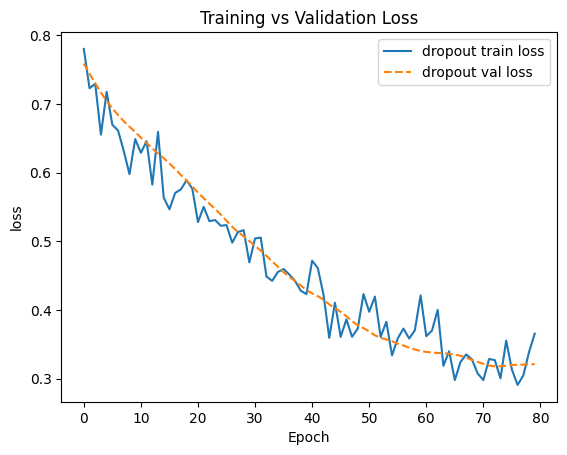

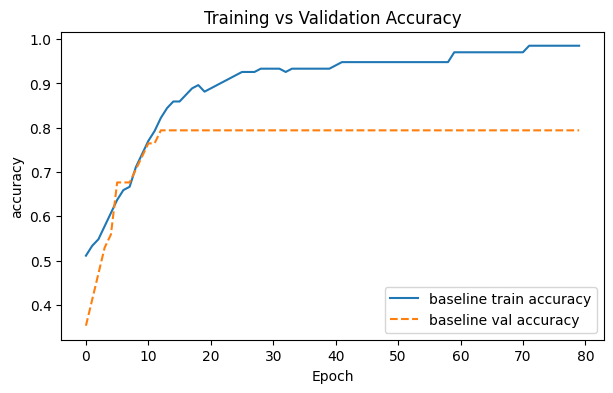

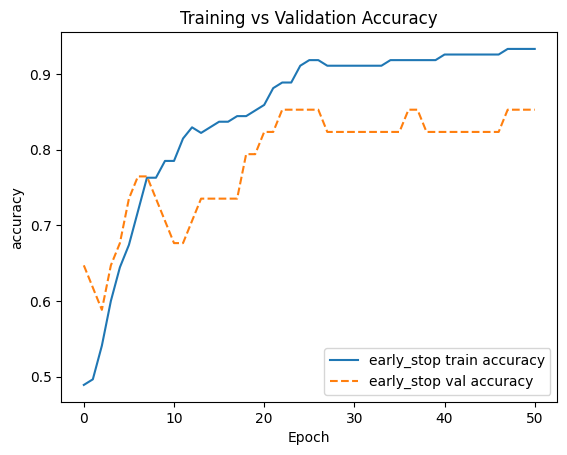

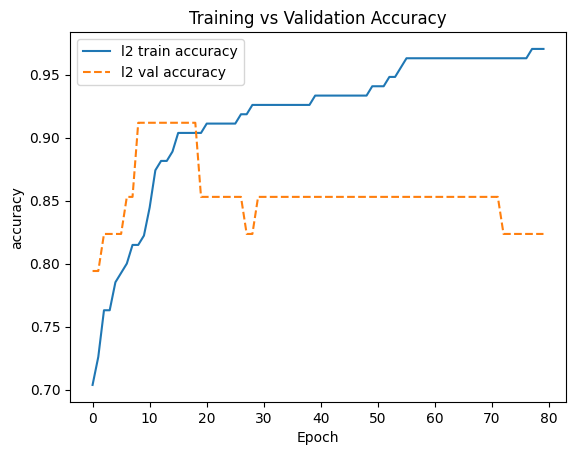

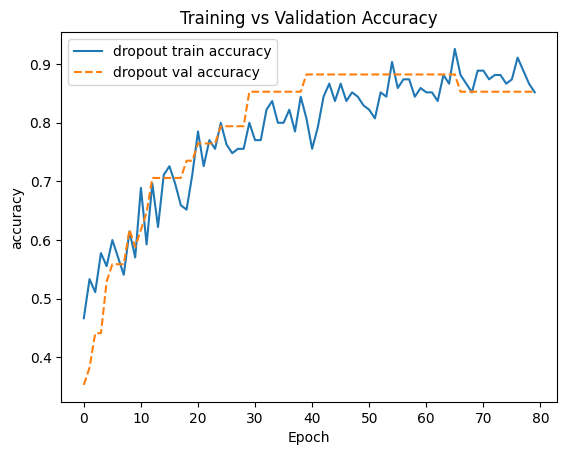

In [26]:
def plot_histories(histories, metric='loss', title=None):
 plt.figure(figsize=(7, 4))
 for name, h in histories.items():
    plt.plot(h.history[metric], label=f"{name} train {metric}")
    plt.plot(h.history[f"val_{metric}"], linestyle='--', label=f"{name} val {metric}")
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.legend()
    plt.show()

histories = {
 'baseline': hist_baseline,
 'early_stop': hist_es,
 'l2': hist_l2,
 'dropout': hist_do,
}

plot_histories(histories, metric='loss', title='Training vs Validation Loss')
plot_histories(histories, metric='accuracy', title='Training vs Validation Accuracy')


PermutationExplainer explainer: 92it [00:10, 10.05s/it]                
/tmp/ipykernel_307/695259736.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test_scaled_df.iloc[:200])


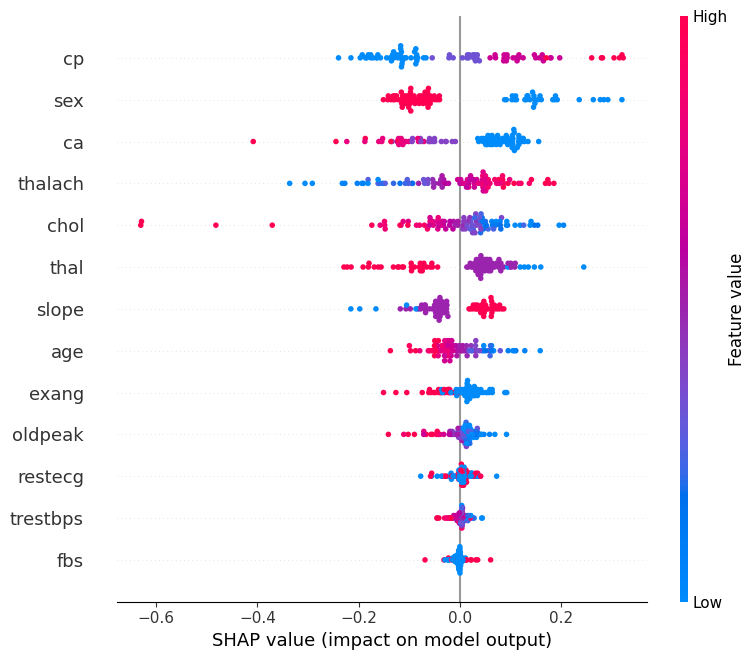

In [27]:
import shap

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

explainer = shap.Explainer(baseline, X_train_scaled)
shap_values = explainer(X_test_scaled_df.iloc[:200])
shap.summary_plot(shap_values, features=X_test_scaled_df.iloc[:200])

## 7. Train a Boosted Decision Tree (BDT)

In [47]:
from xgboost import XGBClassifier

eval_set = [(X_train, y_train), (X_val, y_val)]


xgb_baseline = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    random_state=42
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

evals_base = xgb_baseline.evals_result()


xgb_regularized = XGBClassifier(
    # Give a larger cap and let early stopping choose the effective number of trees.
    n_estimators=500,
    learning_rate=0.02,
    max_depth=3,

    # Overfitting mitigation knobs (BDT equivalents of regularization)
    min_child_weight=5, # Minimum sum of instance weight (roughly: min samples) needed in a child. Higher => less overfitting.
    gamma=0.2, # Minimum loss reduction required to make a split. Higher => simpler trees.
    subsample=0.8, # Row subsampling per tree (injects randomness, reduces variance).
    colsample_bytree=0.8, # Feature subsampling per tree (also reduces variance, like “feature dropout”).
    reg_lambda=10.0, # L2 regularization on leaf weights. Higher => less overfit.
    # reg_alpha=0.5, # Optional L1 regularization on leaf weights; can further sparsify/shrink.

    objective="binary:logistic",
    eval_metric=["auc", "logloss"], #By default, early stopping monitors the last metric in "eval_metric".
    early_stopping_rounds=10, # Stop if the monitored validation metric does not improve for N rounds.
    random_state=42
)

xgb_regularized.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False
)

evals_reg = xgb_regularized.evals_result()

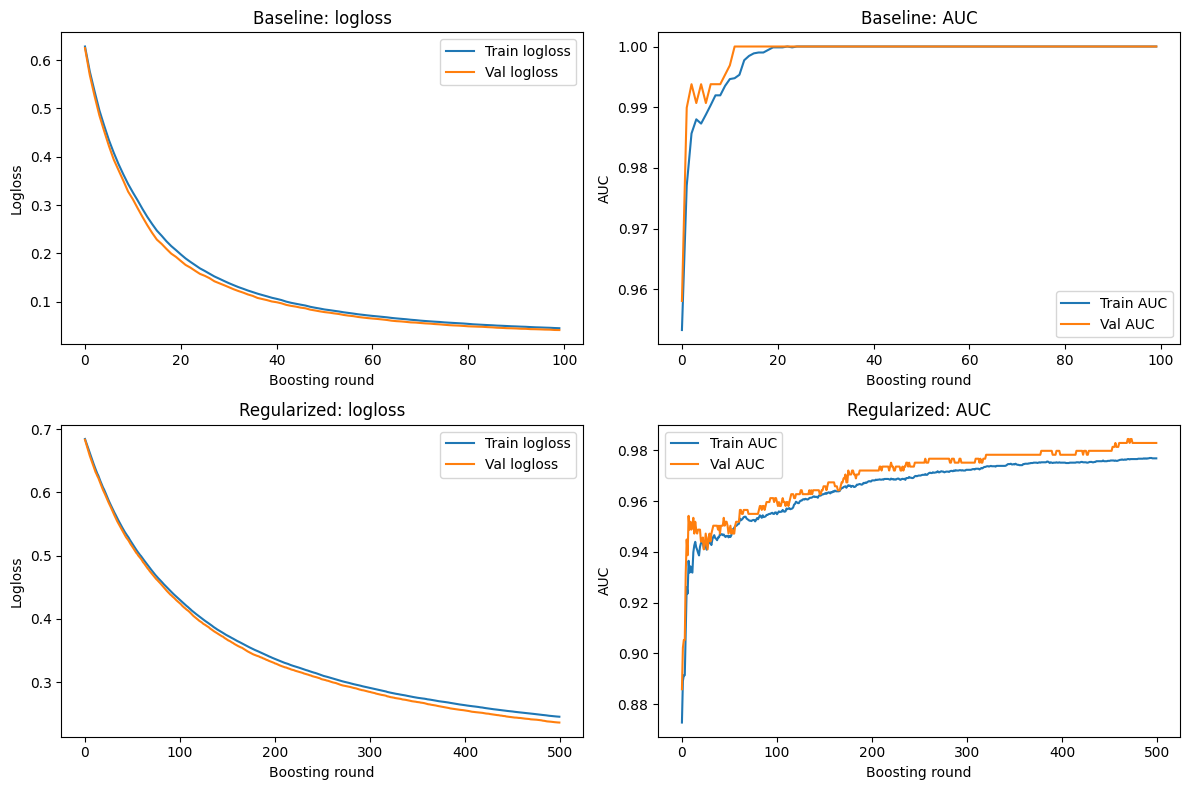

In [48]:
rounds_base = range(len(evals_base["validation_0"]["logloss"]))
rounds_reg  = range(len(evals_reg["validation_0"]["logloss"]))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(rounds_base, evals_base["validation_0"]["logloss"], label="Train logloss")
ax[0, 0].plot(rounds_base, evals_base["validation_1"]["logloss"], label="Val logloss")
ax[0, 0].set(xlabel="Boosting round", ylabel="Logloss", title="Baseline: logloss")
ax[0, 0].legend()

ax[0, 1].plot(rounds_base, evals_base["validation_0"]["auc"], label="Train AUC")
ax[0, 1].plot(rounds_base, evals_base["validation_1"]["auc"], label="Val AUC")
ax[0, 1].set(xlabel="Boosting round", ylabel="AUC", title="Baseline: AUC")
ax[0, 1].legend()

ax[1, 0].plot(rounds_reg, evals_reg["validation_0"]["logloss"], label="Train logloss")
ax[1, 0].plot(rounds_reg, evals_reg["validation_1"]["logloss"], label="Val logloss")
ax[1, 0].set(xlabel="Boosting round", ylabel="Logloss", title="Regularized: logloss")
ax[1, 0].legend()

ax[1, 1].plot(rounds_reg, evals_reg["validation_0"]["auc"], label="Train AUC")
ax[1, 1].plot(rounds_reg, evals_reg["validation_1"]["auc"], label="Val AUC")
ax[1, 1].set(xlabel="Boosting round", ylabel="AUC", title="Regularized: AUC")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

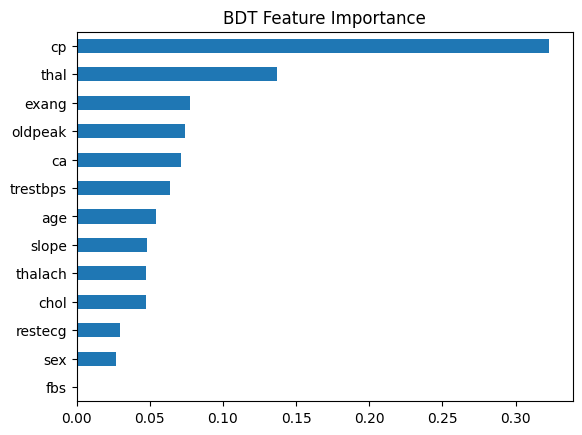

In [37]:
importances = pd.Series(xgb_baseline.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('BDT Feature Importance')
plt.show()

## 8. Prediction Distributions

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


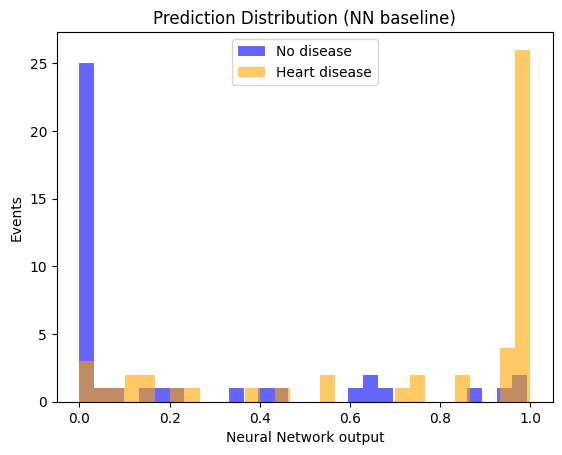

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


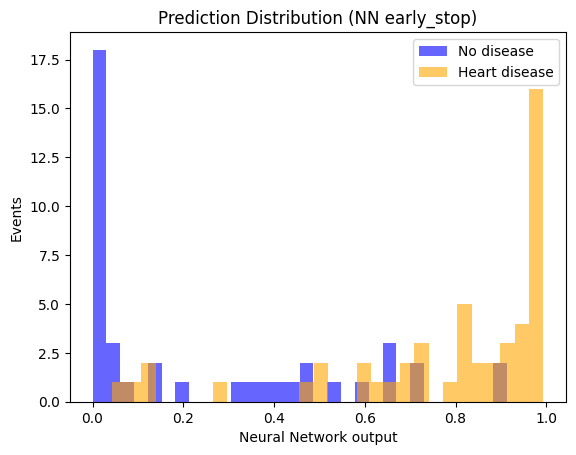

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


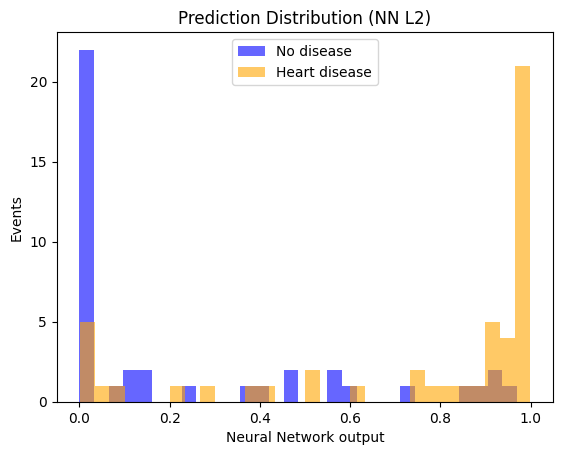

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


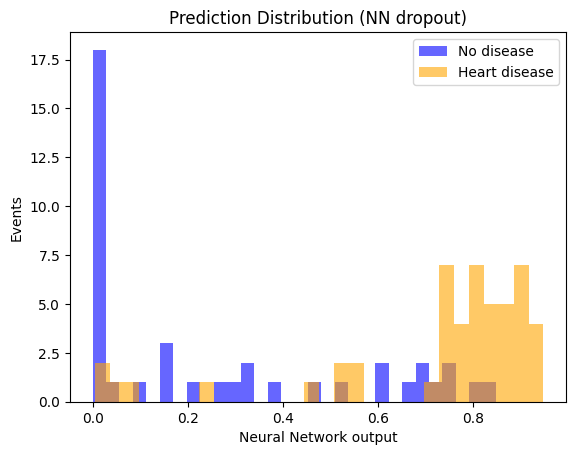

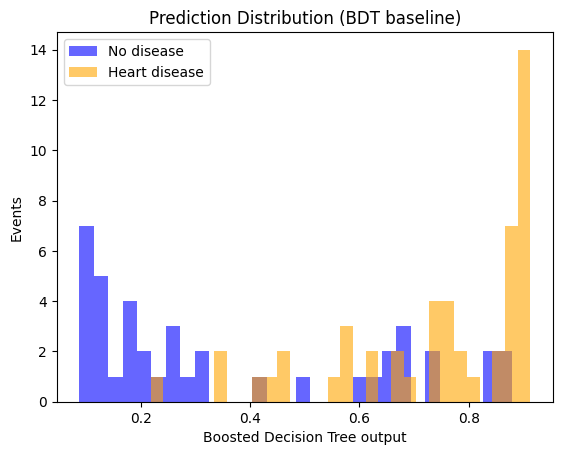

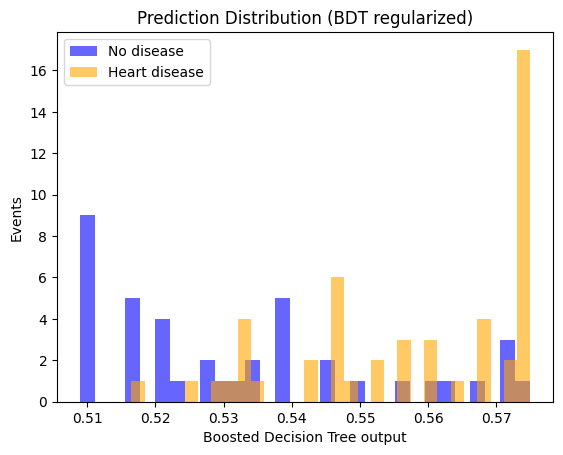

In [38]:
def plot_pred_distribution(name, scores, y, *, xlabel, bins=30):
    plt.figure()
    plt.hist(scores[y == 0], bins=bins, alpha=0.6, label="No disease", color="blue")
    plt.hist(scores[y == 1], bins=bins, alpha=0.6, label="Heart disease", color="orange")
    plt.xlabel(xlabel)
    plt.ylabel("Events")
    plt.legend()
    plt.title(f"Prediction Distribution ({name})")
    plt.show()

# Put EVERYTHING (NNs + BDTs) into one simple list:
models = [
    ("NN baseline",    lambda: baseline.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("NN early_stop",  lambda: es_model.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("NN L2",          lambda: l2_model.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("NN dropout",     lambda: do_model.predict(X_test_scaled).ravel(),  "Neural Network output"),
    ("BDT baseline",   lambda: xgb_baseline.predict_proba(X_test)[:, 1], "Boosted Decision Tree output"),
    ("BDT regularized",lambda: xgb_regularized.predict_proba(X_test)[:, 1], "Boosted Decision Tree output"),
]

for name, get_scores, xlabel in models:
    scores = get_scores()
    plot_pred_distribution(name, scores, y_test, xlabel=xlabel)

## 9. ROC Curve Comparison

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
NN baseline
  Best threshold: 0.708
  Sensitivity: 0.700, Specificity: 0.902
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
NN early_stop
  Best threshold: 0.483
  Sensitivity: 0.900, Specificity: 0.780
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
NN L2
  Best threshold: 0.734
  Sensitivity: 0.720, Specificity: 0.878
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
NN dropout
  Best threshold: 0.731
  Sensitivity: 0.780, Specificity: 0.902
BDT baseline
  Best threshold: 0.169
  Sensitivity: 0.940, Specificity: 0.683
BDT regularized
  Best threshold: 0.324
  Sensitivity: 0.980, Specificity: 0.634


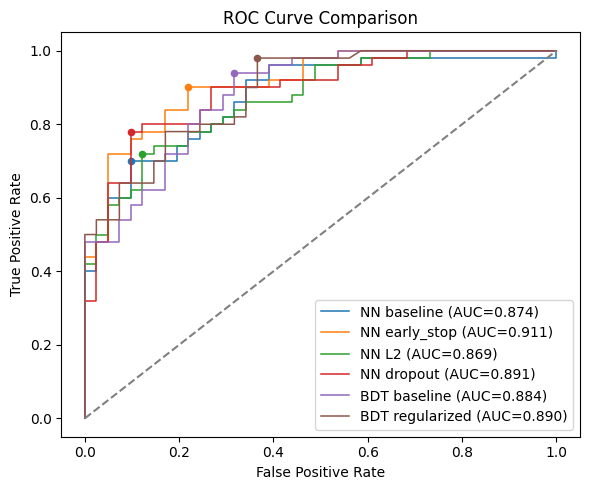

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

def best_threshold(fpr, tpr, thr, w_sens=0.5):
    j = w_sens * tpr - (1 - w_sens) * fpr
    k = int(np.argmax(j))
    return float(thr[k]), float(tpr[k]), float(1 - fpr[k])

keep = {1, 2, 3, 4, 5, 6}

plt.figure(figsize=(6, 5))

for i, (name, get_scores, _) in enumerate(models, start=1):
    if i not in keep:
        continue

    scores = get_scores()
    fpr, tpr, thr = roc_curve(y_test, scores)

    thr_best, sens, spec = best_threshold(fpr, tpr, thr)
    auc = roc_auc_score(y_test, scores)

    print(name)
    print(f"  Best threshold: {thr_best:.3f}")
    print(f"  Sensitivity: {sens:.3f}, Specificity: {spec:.3f}")

    plt.plot(fpr, tpr, linewidth=1.1, label=f"{name} (AUC={auc:.3f})")
    # optional: mark operating point
    plt.scatter([1 - spec], [sens], s=20)

# Chance diagonal
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Medical Evaluation: Sensitivity vs Specificity
In medical diagnostics, missing a heart-disease case (a false negative) can be more harmful than sending a healthy person for follow-up (a false positive). Sensitivity and specificity describe these two error modes: sensitivity (true positive rate) is the fraction of truly sick patients correctly flagged as sick, TP/(TP+FN), while specificity (true negative rate) is the fraction of truly healthy patients correctly cleared as healthy, TN/(TN+FP). There is usually a trade-off: pushing sensitivity up typically reduces specificity, so we need to pick an operating threshold that matches the medical goal.

**Task:**\
Go back to the confusion-matrix code and replace the fixed threshold (0.5) with an automatically chosen threshold that prioritizes sensitivity using a weighted ROC scan (weighted Youden-style objective). The classic Youden index weights sensitivity and specificity equally, but it can be generalized by assigning a higher weight to sensitivity when false negatives are more costly.